# Exploratory Data Analysis: Real Estate Valuation

Before any modeling, this notebook answers four questions about the
[UCI Real Estate Valuation dataset](https://archive.ics.uci.edu/dataset/477/real+estate+valuation+data+set):

1. What does each variable look like on its own?
2. How does each feature relate to the target (price per unit area)?
3. Which features overlap with each other?
4. Are there outliers or quality issues to handle?

Every finding here feeds a modeling hypothesis or decision that is tested in
the modeling stage. This notebook records what the data suggested;
`02_modeling.ipynb` measures which ideas actually improve prediction. The data
itself is loaded through the same `house_prices.data` module the rest of the
project uses, so the notebook and the training code can never disagree about
what the dataset contains.

The complete dataset is loaded only for schema and row-count validation. The
coordinate-group-disjoint holdout is then protected before target-aware EDA.
Every distribution, relationship, correlation, outlier check, and exported
figure below uses only the 331 training rows.

A note on units: the target is the house price of unit area, measured in
**10,000 New Taiwan Dollars per ping** (1 ping = 3.3 m²). A value of 40 means
400,000 TWD per ping.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from house_prices import config
from house_prices.data import load_dataset
from house_prices.train import split_data

sns.set_theme(style="whitegrid", context="notebook")

FIGURES_DIR = config.REPORTS_DIR
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


def save_fig(fig, name):
    """Export a chart so the README and the presentation can reuse it."""
    fig.savefig(FIGURES_DIR / f"{name}.png", dpi=150, bbox_inches="tight")


full_df = load_dataset()
X_train, X_holdout, y_train, _ = split_data(full_df)
df = X_train.copy()
df[config.TARGET_COLUMN] = y_train
print(
    f"Validated {len(full_df)} total rows; exploring {len(df)} training rows and "
    f"protecting {len(X_holdout)} holdout rows."
)
df.head()

Validated 414 total rows; exploring 331 training rows and protecting 83 holdout rows.


,transaction_date,house_age_years,mrt_distance_m,n_convenience_stores,latitude,longitude,price_per_unit_area
No,,,,,,,
1,2012.916667,32.0,84.87882,10,24.98298,121.54024,37.9
3,2013.583333,13.3,561.98450,5,24.98746,121.54391,47.3
4,2013.500000,13.3,561.98450,5,24.98746,121.54391,54.8
5,2012.833333,5.0,390.56840,5,24.97937,121.54245,43.1
6,2012.666667,7.1,2175.03000,3,24.96305,121.51254,32.1


## 1. Overview

`load_dataset()` validates 414 transactions, six features, and one target:
correct columns, numeric types, no missing values, and documented ranges.
The detailed analysis below uses the 331 training rows across 207 locations;
the 83 rows across 52 holdout locations are not inspected here.

In [2]:
print(f"{df.shape[0]} rows, {df.shape[1]} columns, {int(df.isna().sum().sum())} missing values")
df.describe().T.round(2) 


331 rows, 7 columns, 0 missing values


,count,mean,std,min,25%,50%,75%,max
transaction_date,331.0,2013.15,0.28,2012.67,2012.92,2013.17,2013.42,2013.58
house_age_years,331.0,17.91,11.51,0.00,10.05,16.20,28.40,43.80
mrt_distance_m,331.0,1067.23,1233.80,23.38,293.00,492.23,1414.84,6488.02
n_convenience_stores,331.0,4.06,2.86,0.00,1.00,4.00,6.00,10.00
latitude,331.0,24.97,0.01,24.93,24.96,24.97,24.98,25.01
longitude,331.0,121.53,0.02,121.47,121.53,121.54,121.54,121.56
price_per_unit_area,331.0,37.67,12.93,7.60,27.50,38.30,45.60,78.30


The summary table already hints at the two stories of this dataset. Prices
run from 7.6 to 78.3 with a mean around 37.7. Distance to the nearest MRT
station runs from 23 m to 6,488 m, but its mean (1,067 m) sits far above its
median (492 m). That is a classic sign of right skew, which we confirm below.

## 2. The target

Training prices are mildly right-skewed (skewness 0.25): most houses sit
between 20 and 55, with a thinner tail of expensive ones. The protected
holdout is not opened to search for additional extremes.

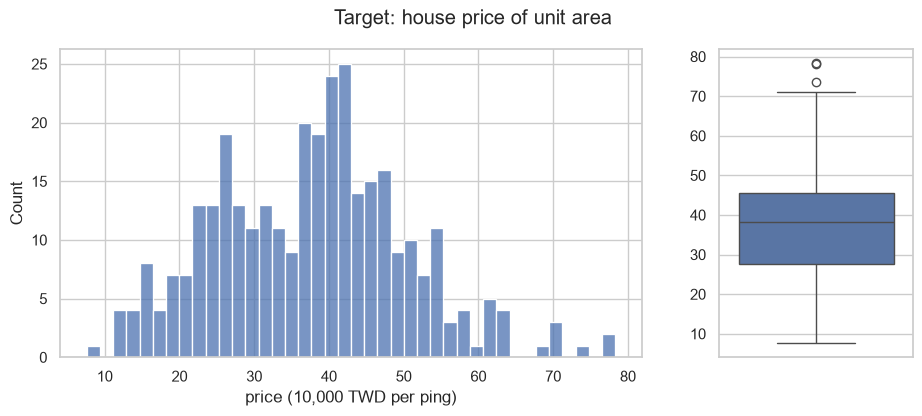

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), width_ratios=[3, 1])
sns.histplot(df[config.TARGET_COLUMN], bins=40, ax=axes[0])
axes[0].set_xlabel("price (10,000 TWD per ping)")
sns.boxplot(y=df[config.TARGET_COLUMN], ax=axes[1])
axes[1].set_ylabel("")
fig.suptitle("Target: house price of unit area")
save_fig(fig, "eda_target_distribution")
plt.show()

## 3. Feature distributions

The histogram grid below is where the feature-engineering plan starts.

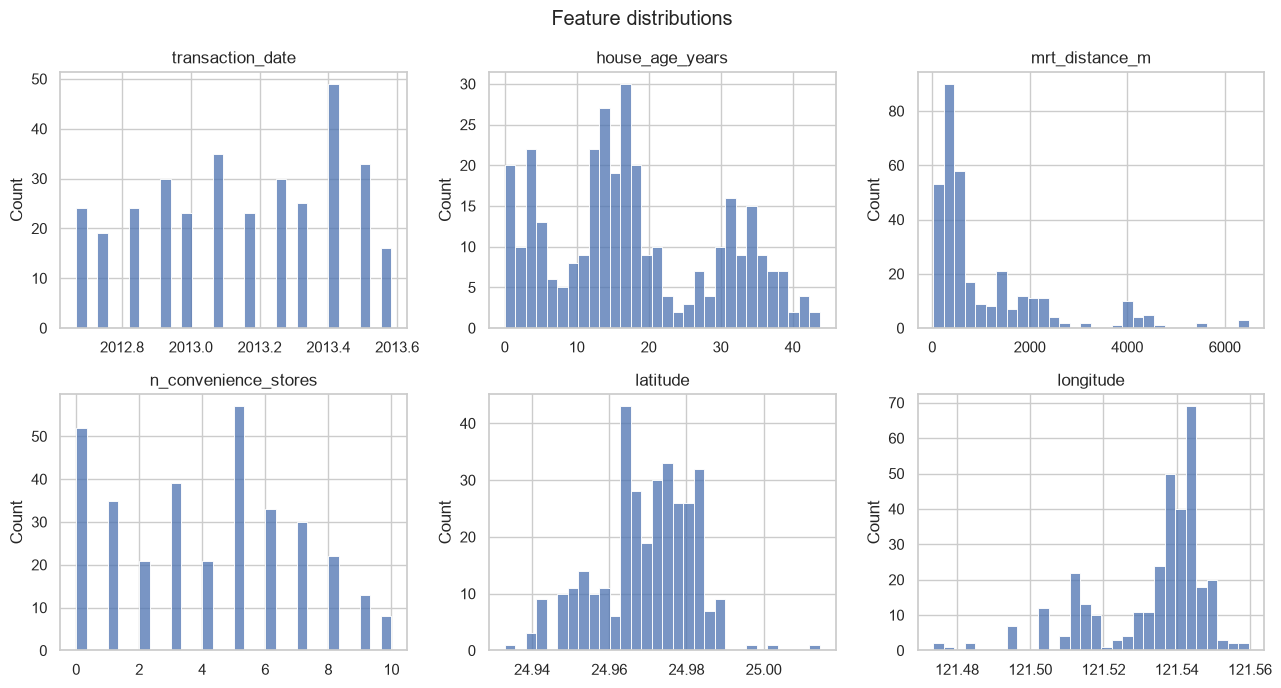

,skewness
mrt_distance_m,2.07
house_age_years,0.34
n_convenience_stores,0.12
transaction_date,-0.19
latitude,-0.36
longitude,-1.37


In [4]:
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, col in zip(axes.flat, config.FEATURE_COLUMNS, strict=True):
    sns.histplot(df[col], bins=30, ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")
fig.suptitle("Feature distributions")
fig.tight_layout()
save_fig(fig, "eda_feature_distributions")
plt.show()

df[config.FEATURE_COLUMNS].skew().round(2).sort_values(ascending=False).to_frame("skewness")

Observations, in order of importance:

- **`mrt_distance_m` is heavily right-skewed** (skewness 2.07). Half the
  houses are within 492 m of a station, three quarters within 1,415 m, and a
  long tail stretches to 6,488 m. A linear model fed the raw values would let
  that tail dominate. This is the strongest argument for a log transform,
  tested in section 4.
- `house_age_years` is bimodal: a large group of nearly new houses (0-10
  years) and another wave around 30-40 years. Age clearly does not act on
  price as a simple straight line. Section 5 quantifies that.
- `n_convenience_stores` is a small integer count (0-10), roughly uniform.
- `transaction_date` covers only 12 months (2012.67-2013.58), so it can
  carry at most a mild market drift.
- `latitude`/`longitude` concentrate in the dense urban core with thin
  edges — they describe *where*, and section 7 shows that geography is the
  price map itself.

## 4. Each feature against price

Two things to look for below: the *direction* of each relationship, and
whether it is straight enough for a linear model.

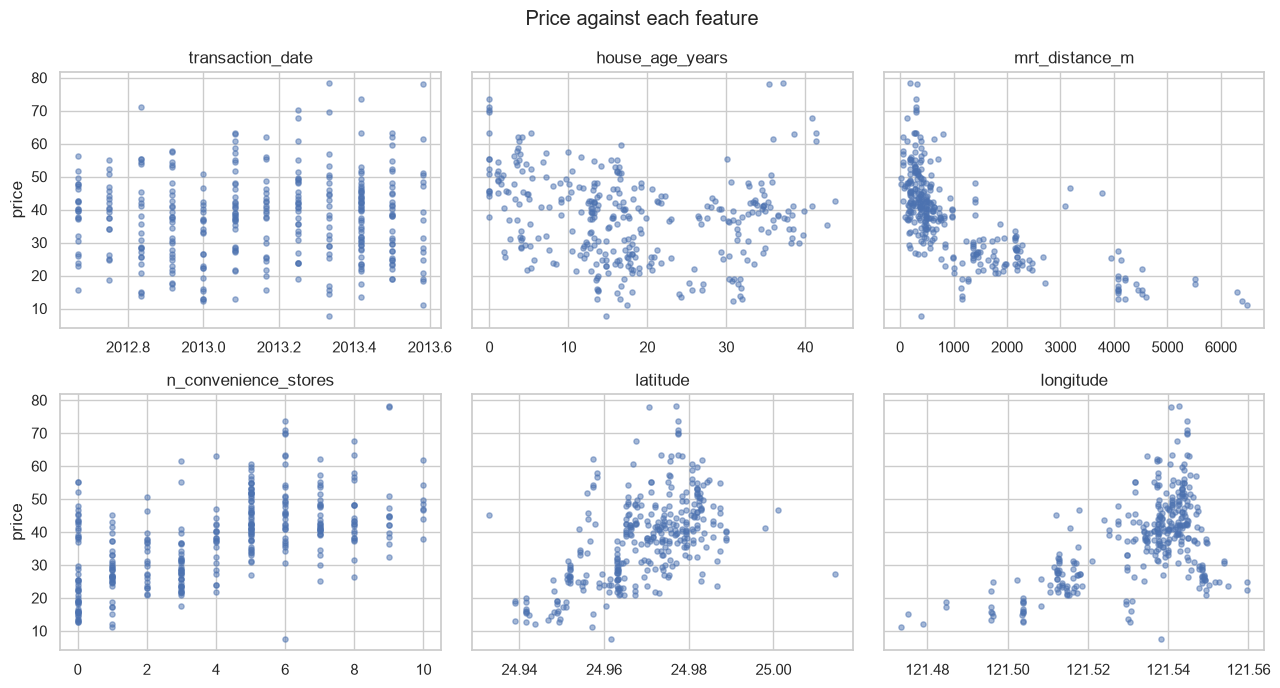

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(13, 7), sharey=True)
for ax, col in zip(axes.flat, config.FEATURE_COLUMNS, strict=True):
    ax.scatter(df[col], df[config.TARGET_COLUMN], s=14, alpha=0.5)
    ax.set_title(col)
for row in axes:
    row[0].set_ylabel("price")
fig.suptitle("Price against each feature")
fig.tight_layout()
save_fig(fig, "eda_price_vs_features")
plt.show()

The MRT panel shows a steep price drop over the first few hundred meters that
flattens with distance. It is a curve, not a line. Compressing distance with a
log makes the relationship close to linear, and the correlation strengthens
from -0.67 to -0.71:

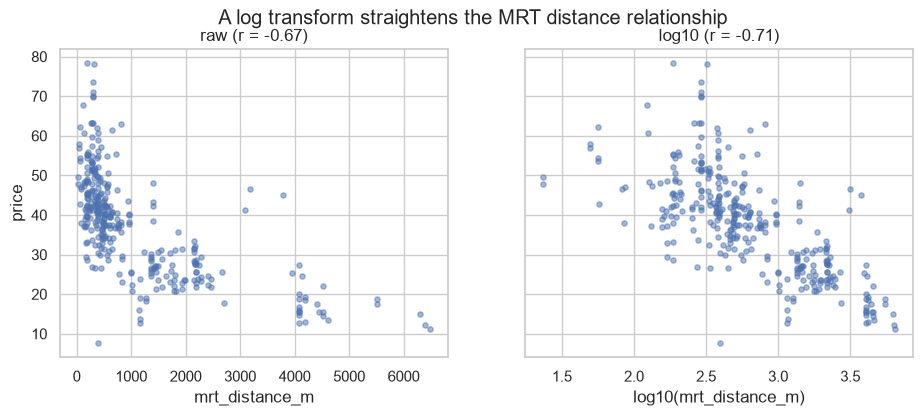

In [6]:
log_mrt = np.log10(df["mrt_distance_m"])
r_raw = df["mrt_distance_m"].corr(df[config.TARGET_COLUMN])
r_log = log_mrt.corr(df[config.TARGET_COLUMN])

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
axes[0].scatter(df["mrt_distance_m"], df[config.TARGET_COLUMN], s=14, alpha=0.5)
axes[0].set(xlabel="mrt_distance_m", ylabel="price", title=f"raw (r = {r_raw:.2f})")
axes[1].scatter(log_mrt, df[config.TARGET_COLUMN], s=14, alpha=0.5)
axes[1].set(xlabel="log10(mrt_distance_m)", title=f"log10 (r = {r_log:.2f})")
fig.suptitle("A log transform straightens the MRT distance relationship")
save_fig(fig, "eda_mrt_log_transform")
plt.show()

This is the intuition behind the transform: for a buyer, the difference
between living 100 m and 600 m from a station is enormous; the difference
between 4,000 m and 4,500 m is barely noticeable. The log scale encodes
exactly that.

**Modeling hypothesis: test `log10(mrt_distance_m)` in place of the raw value
for the linear models.**

## 5. House age is not a straight line

The scatter above already suggested it; average price by age decade confirms
it. Prices fall through the first three decades, then *rebound* for houses
past 40. These are plausibly renovated properties, or locations where land
value dominates the building's age.

In [7]:
df.groupby(df["house_age_years"] // 10 * 10)[config.TARGET_COLUMN].agg(["mean", "count"]).round(1)

,mean,count
house_age_years,,
0.0,45.5,82
10.0,34.3,136
20.0,31.5,36
30.0,37.0,71
40.0,51.8,6


A single linear coefficient cannot express "down, then up". Tree-based models
handle such shapes natively, which is one reason they are on the model
candidate list alongside linear baselines.

**Modeling hypothesis: keep `house_age_years` and test whether a nonlinear
model or an `age²` term captures the observed U-shape better than a plain
linear coefficient.**

## 6. Correlations and feature overlap

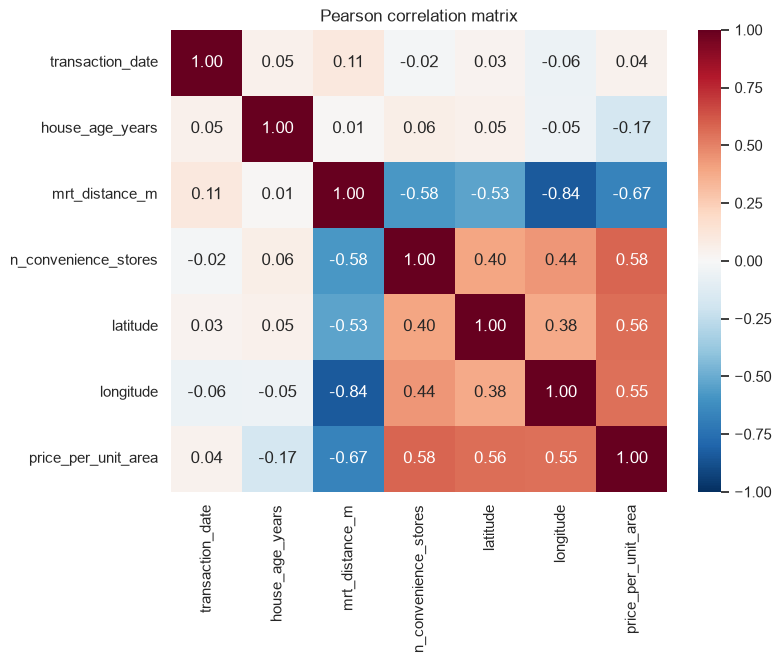

In [8]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title("Pearson correlation matrix")
save_fig(fig, "eda_correlations")
plt.show()

Reading the last row (correlation with price):

| feature | r | reading |
|---|---|---|
| `mrt_distance_m` | -0.67 | strongest single predictor (-0.71 after log) |
| `n_convenience_stores` | +0.58 | more stores, higher price |
| `latitude` | +0.56 | north = closer to the urban core here |
| `longitude` | +0.55 | same story east-west |
| `house_age_years` | -0.17 | weak *linearly*, the U-shape hides its value |
| `transaction_date` | +0.04 | negligible |

Just as important is the overlap *between* features: MRT distance correlates
with longitude at **-0.84**, with convenience stores at -0.58 and latitude at
-0.53. All four are partly measuring the same thing, which is how central the
location is.

**Modeling hypothesis: test Ridge and Lasso, because overlapping predictors
make individual coefficients unstable.** Whether regularization actually
improves prediction is a question for cross-validation, not for this notebook.
Either way, individual coefficient values should be interpreted with care.

`transaction_date` is weakly associated with price (r = 0.04) and covers only
2012 and 2013.

**Modeling hypothesis: test excluding it.** A present-day value would fall
outside the historical period the feature learned its meaning from, so even a
small measured gain may not transfer to production use.

## 7. Geography is the price map

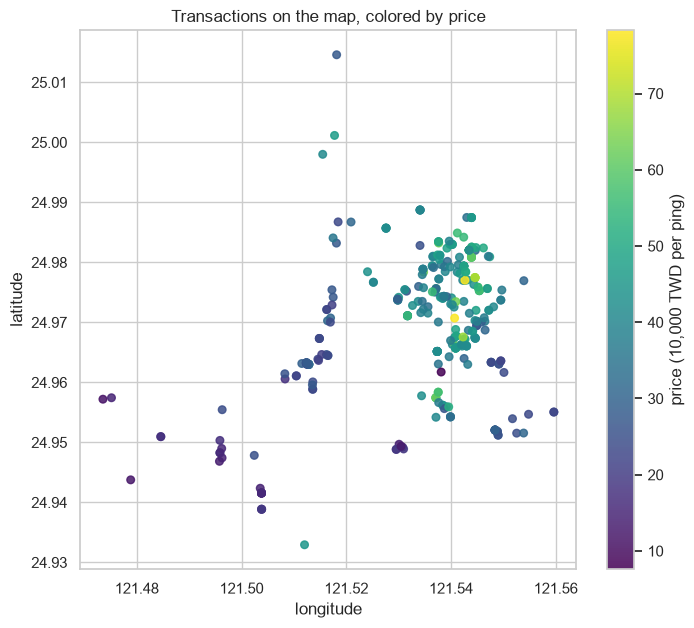

In [9]:
fig, ax = plt.subplots(figsize=(8, 7))
sc = ax.scatter(
    df["longitude"], df["latitude"], c=df[config.TARGET_COLUMN], cmap="viridis", s=30, alpha=0.85
)
fig.colorbar(sc, label="price (10,000 TWD per ping)")
ax.set(xlabel="longitude", ylabel="latitude", title="Transactions on the map, colored by price")
save_fig(fig, "eda_geography")
plt.show()

Expensive houses (yellow) cluster tightly in the dense center; prices fade
outward in every direction. Latitude and longitude are individually crude
predictors, but *together* they encode neighborhood — a tree model can carve
this map into price regions with a handful of splits.

A linear model cannot do that from two coordinates alone, which suggests an
idea worth testing: collapse the pair into a single distance from the centre of
the district, giving a linear model one usable location feature.

**Modeling hypothesis: keep latitude and longitude, and test whether a derived
distance-from-center feature helps the linear model.**

## 8. Outliers

In [10]:
df.nlargest(5, config.TARGET_COLUMN)

,transaction_date,house_age_years,mrt_distance_m,n_convenience_stores,latitude,longitude,price_per_unit_area
No,,,,,,,
221,2013.333333,37.2,186.5101,9,24.97703,121.54265,78.3
313,2013.583333,35.4,318.5292,9,24.97071,121.54069,78.0
167,2013.416667,0.0,292.9978,6,24.97744,121.54458,73.6
106,2012.833333,0.0,292.9978,6,24.97744,121.54458,71.0
17,2013.250000,0.0,292.9978,6,24.97744,121.54458,70.1


The highest training prices are 78.3, 78.0, 73.6, 71.0, and 70.1. Their
profiles are plausible for expensive central properties, and none can be
shown to be a data error. No row is removed on suspicion. The protected
holdout is deliberately not inspected during this decision.

## 9. Findings and modeling hypotheses

| # | Finding | EDA modeling hypothesis / decision |
|---|---|---|
| 1 | `mrt_distance_m` is skewed (2.07) and its price relationship is curved | test `log10(mrt_distance_m)` for linear models |
| 2 | Feature scales differ by orders of magnitude | standardize linear-model inputs inside the pipeline |
| 3 | `house_age_years` has a U-shaped relationship | keep age; test `age²` and nonlinear models |
| 4 | Location-related features overlap (MRT and longitude, r = -0.84) | test Ridge/Lasso; interpret coefficients cautiously |
| 5 | `latitude` and `longitude` jointly encode location | keep both; test distance-from-center as a possible linear helper |
| 6 | `transaction_date` is weak (r = 0.04) and historical | test with and without the date, and evaluate its production meaning |
| 7 | High-price training rows are unusual but plausible | keep them and inspect validation errors |
| 8 | No missing values, all ranges valid | no imputation required |

These are EDA-driven hypotheses, not a final feature list. `02_modeling.ipynb`
tests them with the same cross-validation protocol before deciding what enters
the model that ships.